# Summary statistics across volatility regimes

Builds every number for the paper's summary-statistics table (`tab:summary-stats`) straight from the
three per-regime modeling folders — `low_vol` (**Calm**), `mid_vol` (**Medium**), `high_vol`
(**Turbulent**) — under `ethereum/WETH_USDC/`. Nothing here touches Dune; it only reads the parquets
each `<regime>_vol/modeling/` already holds.

All logic lives in `arblib.summary`; the cells below are call-only. The two rendered tables (plus the
`to_latex()` dumps at the bottom and the methodology notes below) are meant to be **copied into an
LLM to produce the final LaTeX** — the notes give that model the rationale so it formats and captions
the table correctly.


## Methodology — what this table reports and why

**Reference quantile (lead with q20).** q20 is the primary specification throughout the results
section (every model notebook is fit at q20). Larger reference trade sizes (q40, q60, q80) risk
crossing multiple ticks, which contaminates the clean interpretation of the round-trip spread the way
q20 doesn't. So the **main table describes the q20 sample** — exactly the data feeding the main
regressions — and a **compact secondary table** reports just the existence rate across all four
quantiles, as a cheap cross-quantile robustness glance (existence should fall as trade size grows,
consistent with the tick-crossing story; full mean/median/p10/p90 detail at every quantile would just
restate the same message at diminishing informativeness).

**Covariate means (sd) by regime — this validates the regime construction itself.** The whole
three-window design rests on the claim that these are genuinely different volatility/contention
environments, and this block is where that claim is shown empirically rather than asserted:

- **CEX EWMA volatility** must rise monotonically Calm → Medium → Turbulent — it *is* the
  classification variable, so clean separation here is load-bearing for the entire design.
- **MEV intensity, swap frequency, priority fee** — whether these scale with volatility (competition
  intensifies in turbulent periods) or stay flat is itself a citable result about the friction
  channels, feeding the discussion section directly.
- **Base fee, gas utilization** — reported mainly as confound checks: that the three windows don't
  also differ in some unrelated way (e.g. general network congestion). A covariate that moves with the
  regime for a non-volatility reason is a limitation worth flagging.

**Panel-dimension rows = the raw, unconditioned panel.** `N obs (pool-pair × block)` / `N pool-pairs`
/ `N blocks spanned` describe the full extracted panel for each window, **before** any `D==1`
conditioning or risk-set restriction. This table is the single source of truth for *what raw data was
extracted*. The `N` actually used to fit each equation is different for every model — existence/onset
uses the constant-`D`-pair-dropped onset risk set, closure the `gap_lag>0` subset, magnitude the
`D==1` subset with its `min_obs_per_pair` filter, survival the spell count — and each of those belongs
as an "estimation sample" line in that model's own results table, not duplicated here.


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

from arblib import summary as sm, reporting as rp, plotting
from arblib.config import STUDY as S

# Load the three regime panels once (low = Calm, mid = Medium, high = Turbulent).
panels = sm.load_regime_panels(S)
{r: p.shape for r, p in panels.items()}

{'low': (1162431, 27), 'mid': (1162134, 27), 'high': (1117870, 27)}

## Table 1 — main summary statistics (q20)

Sectioned into panel dimensions, the q20 dependent-variable distribution conditional on a gap being
open (`D==1`), and covariate means (sd). One column per regime, ordered Calm → Medium → Turbulent so
a reader sees the volatility gradient left to right.

*Reading it:* CEX EWMA volatility should climb monotonically across the columns (the regime signal);
MEV intensity and swap frequency track whether contention scales with volatility; gas utilization
holding roughly flat is the confound check. `Gap` is in **basis points**; base fee and priority-tip
p90 are shown in **Gwei** (inverted from the stored logs).


In [2]:
main = sm.summary_table(panels, S, quantile=0.2)
main

Calm                   Medium                Turbulent
Section                                  Metric                                                                                                    
Panel dimensions                         Window (UTC, inclusive)          2026-05-12 – 2026-05-17  2026-04-07 – 2026-04-12  2026-02-28 – 2026-03-05
                                         N obs (pool-pair × block)                      1,162,431                1,162,134                1,117,870
                                         N pool-pairs                                          27                       27                       26
                                         N blocks spanned                                  43,053                   43,042                   42,995
Dependent variable: Gap (bps), q20 | D=1 Existence rate, D=1 (%)                             8.11                     6.39                     5.22
                                         Mean Gap | D=1                                     4.205                    4.051                     4.98
                                         Median Gap | D=1                                   2.322                     2.26                    2.767
                                         p10 Gap | D=1                                     0.3292                   0.3149                   0.3993
                                         p90 Gap | D=1                                      9.845                    9.298                    11.61
Covariates: mean (sd)                    Base fee (Gwei)                             0.473 (1.08)          0.1296 (0.0959)           0.1252 (0.169)
                                         Gas utilization                           0.5051 (0.201)           0.5063 (0.225)            0.507 (0.239)
                                         Priority fee p90 (Gwei)                     1.961 (2.95)             1.445 (3.27)             2.337 (22.9)
                                         MEV intensity (venue-avg log1p)             15.91 (4.31)             16.13 (4.19)             16.95 (4.74)
                                         Swap frequency (EWMA/block)               0.3999 (0.438)           0.4385 (0.483)            0.5804 (0.62)
                                         CEX EWMA volatility (×10⁻³)               0.4612 (0.273)           0.6621 (0.335)            1.161 (0.442)

## Table 2 — existence rate across reference quantiles (robustness glance)

Share of pool-pair × block cells with a live executable gap (%) at each reference trade size, by
regime. Existence should collapse as the quantile grows — a larger reference trade crosses more
ticks, so fewer blocks host a clean round-trip gap — which is itself a sanity check that the
trade-size calibration behaves as intended.


In [3]:
existence_xq = sm.existence_cross_quantile_table(panels)
existence_xq

,Calm,Medium,Turbulent
Reference quantile,,,
q20,8.106,6.386,5.223
q40,3.757,1.471,1.611
q60,0.949,0.261,0.290
q80,0.038,0.032,0.033


## Copy-paste for LaTeX

Hand the two rendered tables above (or the `to_latex()` dumps below) plus the methodology notes to an
LLM to produce the final formatted table. The target skeleton the paper uses:

```latex
\begin{table}[h]
\centering
\caption{Summary statistics by volatility regime}
\label{tab:summary-stats}
\begin{tabular}{lccc}
\hline
 & Calm & Medium & Turbulent \\
\hline
\multicolumn{4}{l}{\emph{Panel dimensions}} \\
...
\multicolumn{4}{l}{\emph{Dependent variable, $\mathrm{Gap}_{p,t}$ (bps)}} \\
...
\multicolumn{4}{l}{\emph{Covariates, mean (sd)}} \\
...
\hline
\end{tabular}
\end{table}
```


In [4]:
print(main.to_latex())
print()
print(existence_xq.to_latex(float_format="%.3f"))

\begin{tabular}{lllll}
\toprule
 &  & Calm & Medium & Turbulent \\
Section & Metric &  &  &  \\
\midrule
\multirow[t]{4}{*}{Panel dimensions} & Window (UTC, inclusive) & 2026-05-12 – 2026-05-17 & 2026-04-07 – 2026-04-12 & 2026-02-28 – 2026-03-05 \\
 & N obs (pool-pair × block) & 1,162,431 & 1,162,134 & 1,117,870 \\
 & N pool-pairs & 27 & 27 & 26 \\
 & N blocks spanned & 43,053 & 43,042 & 42,995 \\
\cline{1-5}
\multirow[t]{5}{*}{Dependent variable: Gap (bps), q20 | D=1} & Existence rate, D=1 (%) & 8.11 & 6.39 & 5.22 \\
 & Mean Gap | D=1 & 4.205 & 4.051 & 4.98 \\
 & Median Gap | D=1 & 2.322 & 2.26 & 2.767 \\
 & p10 Gap | D=1 & 0.3292 & 0.3149 & 0.3993 \\
 & p90 Gap | D=1 & 9.845 & 9.298 & 11.61 \\
\cline{1-5}
\multirow[t]{6}{*}{Covariates: mean (sd)} & Base fee (Gwei) & 0.473 (1.08) & 0.1296 (0.0959) & 0.1252 (0.169) \\
 & Gas utilization & 0.5051 (0.201) & 0.5063 (0.225) & 0.507 (0.239) \\
 & Priority fee p90 (Gwei) & 1.961 (2.95) & 1.445 (3.27) & 2.337 (22.9) \\
 & MEV intensity (venue

# Regime × quantile regression tables

The three block-level models — **onset hazard** (logit), **closure hazard** (logit), and
**magnitude** (within pool-pair FE OLS) — refit for *every* regime (Calm / Medium / Turbulent) and
both lead reference quantiles (q20, q40), each assembled into one coefficient table. Same recipes as
notebooks 06 / 07 / 08; here `arblib.reporting` loops them over the regimes, reading each regime's
panel from its own `<regime>_vol` folder — so **nothing depends on `STUDY.active_regime`**. Leave that
setting wherever it is; these tables always cover all three regimes, and you never copy a single
regression out of 06/07/08 by hand.

Each cell is the **coefficient with significance stars** (`***` p<0.01, `**` p<0.05, `*` p<0.10). The
trailing columns are the fit's pseudo / within R², the estimation `N`, and `N_pairs` — the pool-pairs
kept after the constant-`D` and events-per-variable (`min_events_per_pair`) screens. Fixed effects,
clustering, and risk-set definitions are stated per table below and match the paper captions
(`tab:onset`, `tab:closure`, `tab:magnitude`).

Fitting all 18 models takes ~30–40 s.


## Table `tab:onset` — onset hazard (logit)

Risk set `gap_lag == 0`; dependent variable `D = 1[Gap>0]` (a gap *appears* at t). LSDV with
pool-pair and hour-of-day fixed effects, pair-clustered SEs; pseudo R² is McFadden's. `N` = risk-set
observations; `N_pairs` = pool-pairs retained after dropping constant-`D` pairs and the EPV floor.


In [5]:
onset = rp.onset_table(panels, S, quantiles=(0.2, 0.4))
onset

log base fee_t gas util_{t-1} tip p90_{t-1} MEV_{t-1} freq_{t-1}   log σ_t  pseudo R²       N  N_pairs
Regime    q                                                                                                         
Calm      q20       0.246***      -0.388***        -0.011  0.178***   0.502***  0.674***     0.1849  724132       19
          q40       0.308***      -0.306***        -0.008  0.195***   0.498***  0.669***     0.2045  774427       19
Medium    q20       0.399***      -0.226***      0.030***  0.127***   0.440***  0.576***     0.2050  743615       19
          q40       0.680***      -0.310***         0.009  0.145***   0.442***  0.542***     0.2536  628611       15
Turbulent q20       0.522***      -0.357***        -0.009  0.117***   0.469***  0.502***     0.2464  630015       16
          q40       0.661***      -0.403***      -0.029**  0.145***   0.505***  0.863***     0.2196  583913       14

## Table `tab:closure` — closure hazard (logit)

Risk set `gap_lag > 0` (a gap is open at t-1); dependent variable `D = 1` if the gap *survives* to
block t, conditional on `D_{t-1}=1`. Adds spell age (`spell dur.`) and the open-gap size
`log(1+gap_{t-1})`. Same fixed effects / pair-clustered SEs / pseudo R² as the onset table.


In [6]:
closure = rp.closure_table(panels, S, quantiles=(0.2, 0.4))
closure

log base fee_t gas util_{t-1} tip p90_{t-1}  MEV_{t-1} freq_{t-1}    log σ_t spell dur. log(1+gap_{t-1})  pseudo R²      N  N_pairs
Regime    q                                                                                                                                      
Calm      q20       0.357***       0.415***         0.003  -0.069***  -0.237***    -0.090*   0.011***            0.128     0.0659  93552       19
          q40       0.488***       0.353***         0.011  -0.061***  -0.167***  -0.099***   0.015***           -0.010     0.0733  43134       18
Medium    q20       0.574***         0.057*        -0.003  -0.056***    -0.141*  -0.153***   0.016***            0.026     0.0647  73601       16
          q40       0.695***      -0.225***     -0.024***     -0.015     -0.014  -0.187***      0.017           -0.033     0.0533  16334       10
Turbulent q20       0.526***       0.123***        -0.005  -0.045***      0.043  -0.115***   0.021***            0.051     0.0730  57186       13
          q40       0.404***       -0.142**        -0.012     -0.020    0.087**   0.300***   0.053***          0.105**     0.0813  17364       11

## Table `tab:magnitude` — magnitude (within pool-pair FE OLS)

Conditional on existence (`D == 1`); dependent variable `log Gap`. Pool-pair fixed effects swept out
by the within transformation (**no** hour effects), two-way (pool-pair × block) clustered SEs. Within
R² is reported (Between / Overall R² are unreliable on this unbalanced, few-entity panel). `N` =
`D==1` observations after the minimum-rows-per-pair floor.


In [7]:
mag = rp.magnitude_table(panels, S, quantiles=(0.2, 0.4))
mag

log base fee_t gas util_{t-1} tip p90_{t-1} MEV_{t-1} freq_{t-1}   log σ_t log(1+gap_{t-1})  within R²      N  N_pairs
Regime    q                                                                                                                         
Calm      q20       0.106***      -0.076***         0.005   0.014**   0.164***  0.222***         0.783***     0.3257  94111       24
          q40       0.175***      -0.105***         0.010   0.023**   0.182***  0.237***         0.633***     0.2626  43522       22
Medium    q20       0.189***      -0.123***        -0.002  0.034***   0.202***  0.186***         0.582***     0.2022  74067       21
          q40         0.104*      -0.127***         0.002  0.034***   0.223***  0.231***         0.353***     0.0926  16954       17
Turbulent q20       0.158***      -0.199***     -0.015***  0.049***   0.194***  0.381***         0.392***     0.1796  58261       22
          q40         -0.017        -0.122*      -0.015**  0.066***   0.152***  0.509***         0.298***     0.0980  17838       15

## Copy-paste for LaTeX

`to_latex()` for all three coefficient tables — hand these (with the paper captions) to an LLM to
slot into the `tab:onset` / `tab:closure` / `tab:magnitude` layouts. The `\multirow` regime grouping
and `\shortstack` column heads are cosmetic; the numbers are what matter.


In [8]:
for name, tbl in [("onset", onset), ("closure", closure), ("magnitude", mag)]:
    print(f"% ===== {name} =====")
    print(tbl.to_latex())
    print()

% ===== onset =====
\begin{tabular}{llllllllrrr}
\toprule
 &  & log base fee_t & gas util_{t-1} & tip p90_{t-1} & MEV_{t-1} & freq_{t-1} & log σ_t & pseudo R² & N & N_pairs \\
Regime & q &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{Calm} & q20 & 0.246*** & -0.388*** & -0.011 & 0.178*** & 0.502*** & 0.674*** & 0.184900 & 724132 & 19 \\
 & q40 & 0.308*** & -0.306*** & -0.008 & 0.195*** & 0.498*** & 0.669*** & 0.204500 & 774427 & 19 \\
\cline{1-11}
\multirow[t]{2}{*}{Medium} & q20 & 0.399*** & -0.226*** & 0.030*** & 0.127*** & 0.440*** & 0.576*** & 0.205000 & 743615 & 19 \\
 & q40 & 0.680*** & -0.310*** & 0.009 & 0.145*** & 0.442*** & 0.542*** & 0.253600 & 628611 & 15 \\
\cline{1-11}
\multirow[t]{2}{*}{Turbulent} & q20 & 0.522*** & -0.357*** & -0.009 & 0.117*** & 0.469*** & 0.502*** & 0.246400 & 630015 & 16 \\
 & q40 & 0.661*** & -0.403*** & -0.029** & 0.145*** & 0.505*** & 0.863*** & 0.219600 & 583913 & 14 \\
\cline{1-11}
\bottomrule
\end{tabular}


% ===== closure =====
\be

# Regressor correlation heatmaps, by regime

Pearson correlation among the block-level model regressors — the same covariates that appear in the
coefficient tables above — computed over the full q20 model frame (every pool-pair × block row with
its lags defined), **one heatmap per regime**. The diverging scale is fixed at [−1, 1] and shared
across the three panels, so a given cell's colour is directly comparable across regimes.

This is the multicollinearity read for the regressions, and nothing is alarming: the environment
covariates are only mildly correlated, the strongest pairs being **base fee ↔ log σ** (base fee and
volatility move together, most so in the turbulent window) and **MEV ↔ freq** (contention and
order-flow co-move). `gas util` and `tip p90` are near-orthogonal to everything. Note
`log(1+gap_{t-1})` and `spell dur.` are lagged-state terms that are 0 off-spell (the large majority of
rows), so their ~0.6 mutual correlation is mechanical (both non-zero only on open-spell blocks), not
economic — read the top-left 6×6 environment block for the diagnostic that matters.


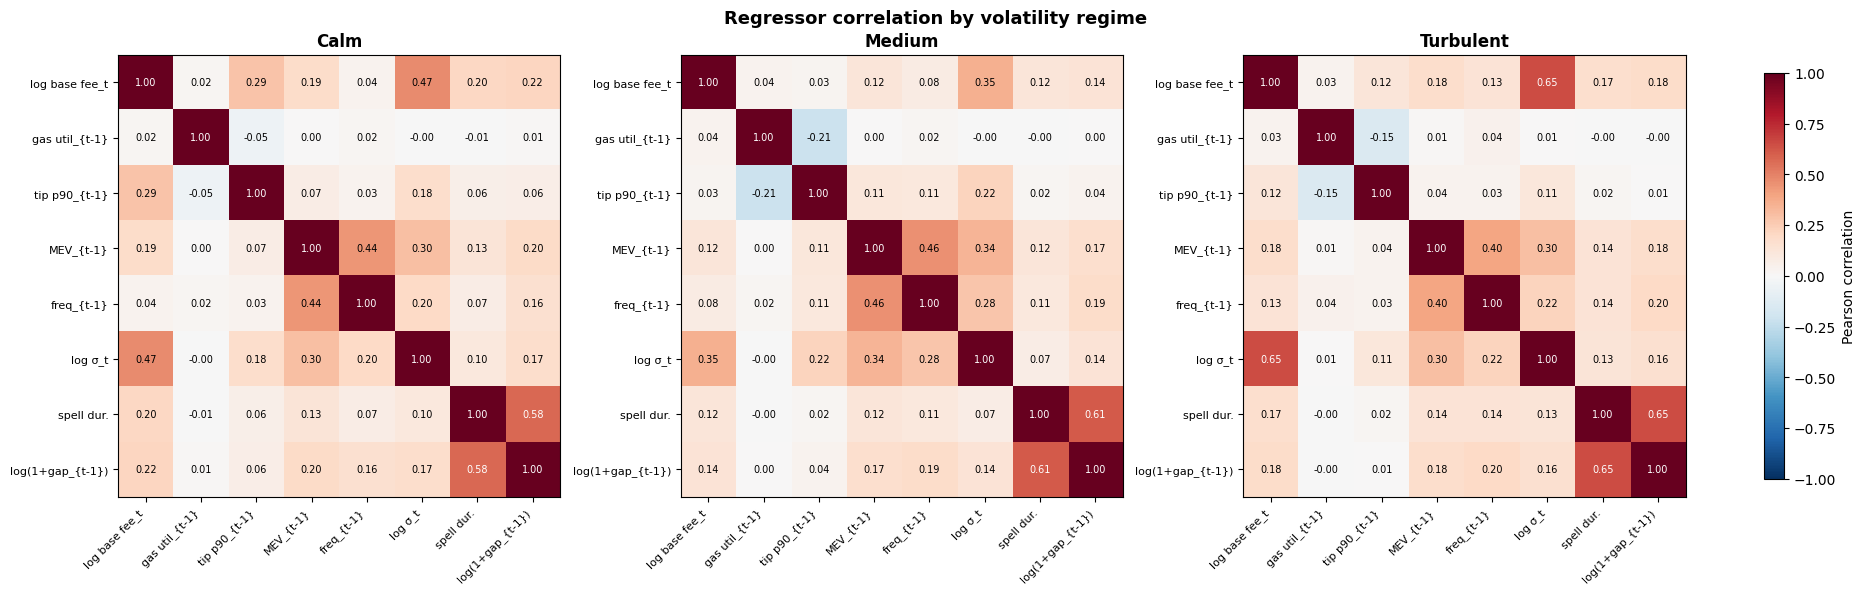

In [9]:
corr_by_regime = rp.covariate_correlations(panels, quantile=0.2)
plotting.plot_correlation_heatmaps(corr_by_regime)

The numeric matrices are in `corr_by_regime` (keyed `"Calm"` / `"Medium"` / `"Turbulent"`)
if you want to drop the values into the paper — e.g. `corr_by_regime["Turbulent"].round(2)`.
